In [1]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging/deep_hedging


In [2]:
import numpy as np
import pandas as pd
from src.models.heston import simulate_heston

In [3]:
S0 = 100.0

v0 = 0.20**2
theta = 0.20**2

kappa = 2.0
xi = 0.40
rho = -0.70

r = 0.0
T = 1.0

n_steps = 252
n_paths = 100_000

In [4]:
result = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_paths,
    r=r,
    seed=123
)

spot_paths, variance_paths = result.spot, result.variance

print(spot_paths.shape)
print(variance_paths.shape)

(100000, 253)
(100000, 253)


In [5]:
assert np.all(spot_paths > 0)
assert np.all(variance_paths >= 0)

mean_variance = variance_paths.mean(axis=0)
mean_variance

array([0.04      , 0.04000667, 0.04003906, 0.04004   , 0.04003958,
       0.04003441, 0.04003102, 0.04005402, 0.04006531, 0.0401039 ,
       0.04010015, 0.04012649, 0.04012863, 0.04014489, 0.04014795,
       0.04012225, 0.04011541, 0.04010734, 0.04011381, 0.04011289,
       0.04011074, 0.04013477, 0.04012524, 0.04012372, 0.04014223,
       0.04012708, 0.04012851, 0.04012299, 0.04012966, 0.0400984 ,
       0.04008952, 0.04008578, 0.0400628 , 0.04006506, 0.04007057,
       0.04008958, 0.04006069, 0.04006538, 0.04003421, 0.03999715,
       0.03998438, 0.04000587, 0.03999587, 0.03999598, 0.03997351,
       0.03997652, 0.03997671, 0.03997299, 0.03998298, 0.03995294,
       0.03997585, 0.03996191, 0.03995256, 0.03995958, 0.03996016,
       0.03996598, 0.03994967, 0.03994139, 0.03993385, 0.03992332,
       0.03992515, 0.03992576, 0.03990858, 0.03988813, 0.03990219,
       0.03990796, 0.03988052, 0.03989414, 0.03989553, 0.03988816,
       0.03986389, 0.03988518, 0.03989683, 0.03990483, 0.03989

In [6]:
rng = np.random.default_rng(123)

Z_v = rng.standard_normal(1_000_000)
Z_independent = rng.standard_normal(1_000_000)

Z_s = (
    rho * Z_v
    + np.sqrt(1 - rho**2)
    * Z_independent
)

print(
    np.corrcoef(Z_s, Z_v)[0, 1]
)

-0.6999716847301107


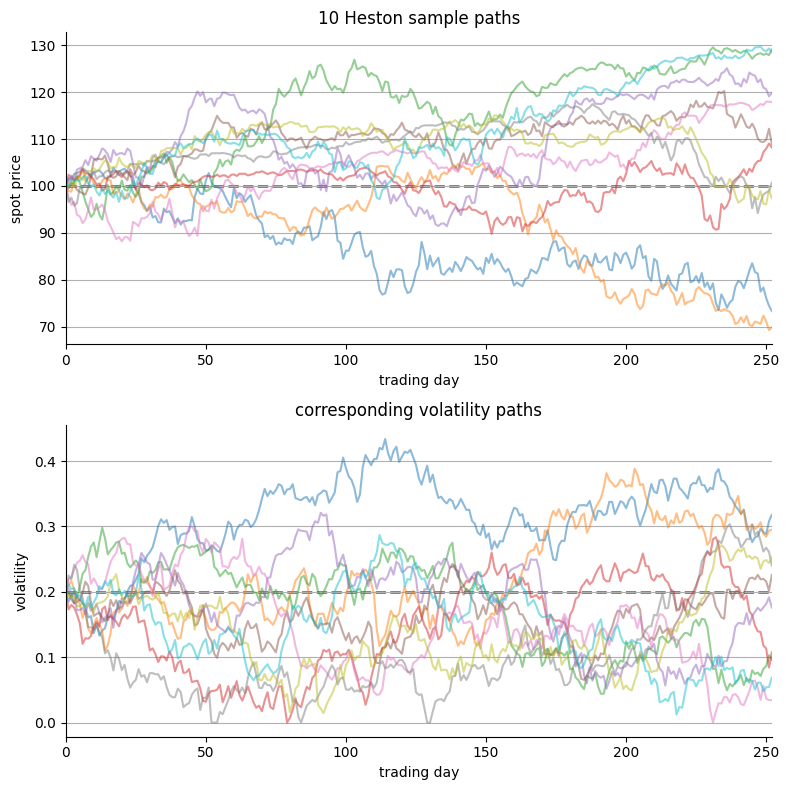

In [47]:
import matplotlib.pyplot as plt

sample_paths = 10

vol_paths = np.sqrt(variance_paths)

t = np.linspace(0, T, n_steps + 1) * 252  # x-axis in trading days

fig, (ax_spot, ax_vol) = plt.subplots(2, 1, figsize=(8, 8))

ax_spot.plot(t, spot_paths[:sample_paths].T, alpha=0.5)
ax_spot.axhline(S0, color="steelblue", linewidth=2, linestyle="--", zorder=0)

ax_spot.set_title(f"{sample_paths} Heston sample paths")
ax_spot.set_ylabel("spot price")

ax_vol.plot(t, vol_paths[:sample_paths].T, alpha=0.5)
ax_vol.axhline(np.sqrt(theta), color="steelblue", linewidth=2, linestyle="--", zorder=0)

ax_vol.set_title("corresponding volatility paths")
ax_vol.set_ylabel("volatility")

for ax in (ax_spot, ax_vol):
    ax.set_xlabel("trading day")
    ax.set_xlim(0, t[-1])
    ax.grid(axis="y")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

fig.tight_layout()
plt.show()

# testing on delta hedge

In [8]:
from src.strategies.delta_hedge import run_delta_hedge

In [9]:
frequencies = [1, 4, 12, 52, 252]

results = []
pnl_by_frequency = {}

for n_steps in frequencies:
    result = simulate_heston(
        S0=S0,
        v0=v0,
        kappa=kappa,
        theta=theta,
        xi=xi,
        rho=rho,
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        r=r,
        seed=123 + n_steps
    )

    spot_paths, variance_paths = result.spot, result.variance

    hedge = run_delta_hedge(
        stock_paths=spot_paths,
        K=100.0,
        sigma=0.20,
        T=T,
        r=r,
        record_history=False
    )

    pnl = hedge["pnl"]

    mean_pnl = np.mean(pnl)
    std_pnl = np.std(pnl, ddof=1)
    standard_error = std_pnl / np.sqrt(n_paths)

    results.append({
        "n_steps": n_steps,
        "mean_pnl": mean_pnl,
        "std_pnl": std_pnl,
        "se_mean": standard_error,
    })

    pnl_by_frequency[n_steps] = pnl

results = pd.DataFrame(results)

print(results)

   n_steps  mean_pnl   std_pnl   se_mean
0        1  0.049848  6.005992  0.018993
1        4  0.350870  4.139000  0.013089
2       12  0.507000  2.790751  0.008825
3       52  0.559026  2.148795  0.006795
4      252  0.559673  1.968828  0.006226


# comparison to GBM

In [11]:
from src.models.gbm import simulate_gbm

gbm_paths = simulate_gbm(
    S0=100.0,
    sigma=0.20,
    T=1.0,
    n_steps=252,
    n_paths=100_000,
    r=0.0,
    seed=123
).spot

gbm_result = run_delta_hedge(
    stock_paths=gbm_paths,
    K=100.0,
    sigma=0.20,
    T=1.0,
    r=0.0
)

In [12]:
result = simulate_heston(
    S0=100.0,
    v0=0.04,
    kappa=2.0,
    theta=0.04,
    xi=0.40,
    rho=-0.70,
    T=1.0,
    n_steps=252,
    n_paths=100_000,
    r=0.0,
    seed=123
)

heston_spot, heston_variance = result.spot, result.variance

heston_result = run_delta_hedge(
    stock_paths=heston_spot,
    K=100.0,
    sigma=0.20, # deliberately fixed
    T=1.0,
    r=0.0
)

In [37]:
gbm_terminal_returns = np.log(gbm_paths[:, -1] / S0)
heston_terminal_returns = np.log(heston_spot[:, -1] / S0)

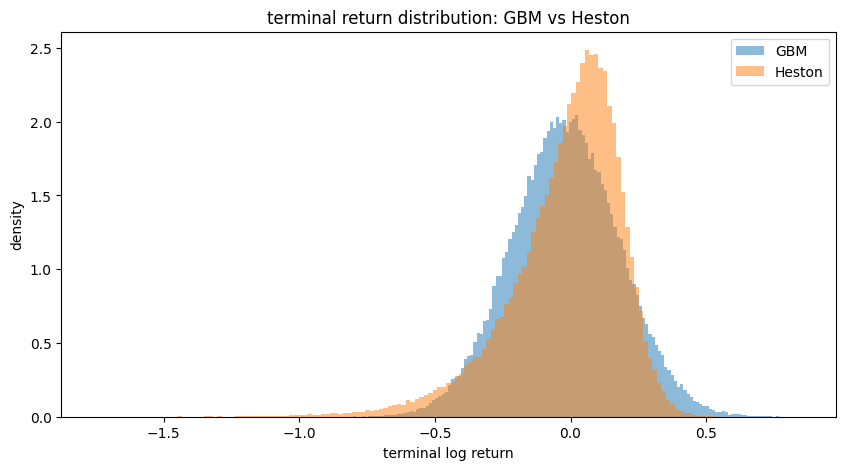

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(
    gbm_terminal_returns,
    bins=150,
    density=True,
    alpha=0.5,
    label="GBM",
)

plt.hist(
    heston_terminal_returns,
    bins=150,
    density=True,
    alpha=0.5,
    label="Heston",
)

plt.xlabel("terminal log return")
plt.ylabel("density")
plt.title("terminal return distribution: GBM vs Heston")
plt.legend()
plt.show()

In [44]:
gbm_pnl = gbm_result["pnl"]
heston_pnl = heston_result["pnl"]

gbm_centered = gbm_pnl - gbm_pnl.mean()
heston_centered = heston_pnl - heston_pnl.mean()

print("GBM:", np.mean(gbm_pnl), np.std(gbm_pnl))
print("  centered:", np.mean(gbm_centered))
print("Heston:", np.mean(heston_pnl), np.std(heston_pnl))
print("  centered:", np.mean(heston_centered))

GBM: 0.0020481162770799913 0.4383002854622733
  centered: -8.455458555545193e-18
Heston: 0.5439009570436795 1.9823717500732643
  centered: -7.105427357601002e-18


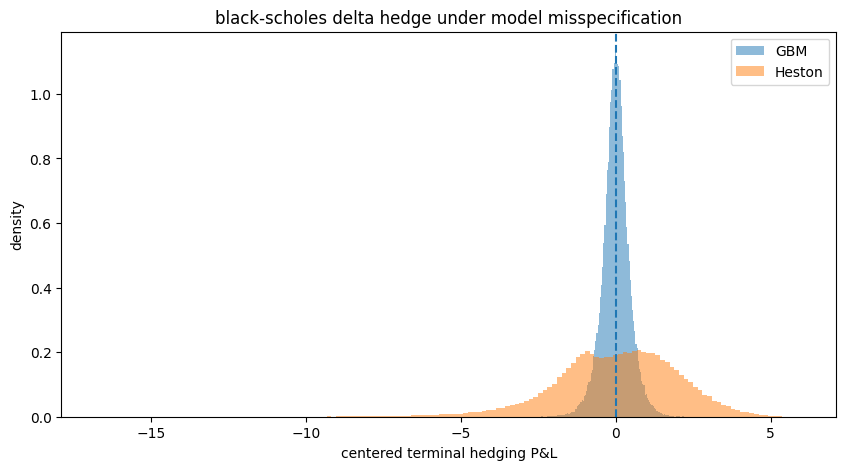

In [55]:
plt.figure(figsize=(10, 5))

plt.hist(
    gbm_centered,
    bins=150,
    density=True,
    alpha=0.5,
    label="GBM",
)

plt.hist(
    heston_centered,
    bins=150,
    density=True,
    alpha=0.5,
    label="Heston",
)

plt.axvline(0, linestyle="--")

plt.xlabel("centered terminal hedging P&L")
plt.ylabel("density")
plt.title("black-scholes delta hedge under model misspecification")
plt.legend()
plt.show()

# error vs xi

In [59]:
xis = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

records = []

for xi_test in xis:
    result = simulate_heston(
        S0=S0,
        v0=0.04,
        theta=0.04,
        kappa=2.0,
        xi=xi_test,
        rho=-0.7,
        T=T,
        n_steps=252,
        n_paths=50_000,
        r=0.0,
        seed=123 + int(xi_test * 10)
    )

    spot, variance = result.spot, result.variance

    hedge = run_delta_hedge(
        stock_paths=spot,
        K=100.0,
        sigma=0.20,
        T=T,
        r=0.0
    )

    pnl = hedge["pnl"]

    records.append({
        "xi": xi_test,
        "mean_pnl": np.mean(pnl),
        "std_pnl": np.std(pnl, ddof=1)
    })

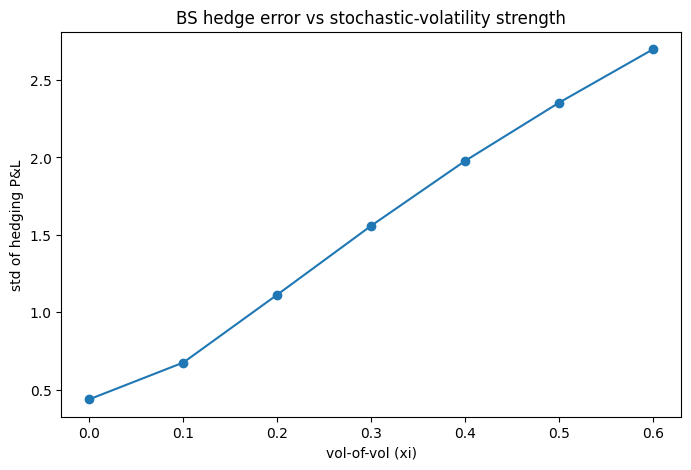

In [60]:
xi_values = [x["xi"] for x in records]
std_values = [x["std_pnl"] for x in records]

plt.figure(figsize=(8, 5))

plt.plot(xi_values, std_values, marker="o")
plt.xlabel("vol-of-vol (xi)")
plt.ylabel("std of hedging P&L")
plt.title("BS hedge error vs stochastic-volatility strength")
plt.show()

# error vs rho

In [ ]:
rhos = [-0.9, -0.7, -0.5, -0.3, 0.0, 0.3]

records = []

for rho_test in rhos:
    result = simulate_heston(
        S0=S0,
        v0=0.04,
        theta=0.04,
        kappa=2.0,
        xi=0.40,
        rho=rho_test,
        T=T,
        n_steps=252,
        n_paths=50_000,
        r=0.0,
        seed=123 + int(rho_test * 10)
    )

    spot, variance = result.spot, result.variance

    hedge = run_delta_hedge(
        stock_paths=spot,
        K=100.0,
        sigma=0.20,
        T=T,
        r=0.0
    )

    pnl = hedge["pnl"]

    records.append({
        "xi": xi_test,
        "mean_pnl": np.mean(pnl),
        "std_pnl": np.std(pnl, ddof=1)
    })